# The argument from poverty of the stimulus

Take up Pullum's challenge to Lightfoot concerning the learnability of auxiliary reduction. Specifically, determine whether a simple probabilistic model can learn the correct hypothesis concerning such reduction, from a corpus of child-directed speech.

## Background

Lightfoot 1998 argues that children can of course learn that the word 'is' can be reduced in certain contexts:

> 1a. Kim is happy.  
> 1b. Kim's happy.

because both forms are attested.  However there are many other contexts in which 'is' cannot be reduced - here are his examples, with the relevant 'is' *highlighted*:

> 2a. Kim's taller than Jim *is*.  

> 2b. I don't know what that *is* up there.  

> 2c. Kim is drinking more Coke than Jim *is* coffee. 

> 2d. I don't know where the concert *is* next week.  

Lightfoot adds: 
> Crain (1991) showed that [this knowledge of when 'is' can vs. cannot be reduced is found in] young children at the earliest stage that they can be tested. Linguists have proposed domain-specific principles, elements of UG, which preclude reduction in such contexts; they relate to the nature of rightward cliticization.

Pullum 2011: 
>Lightfoot (1998: 585) suggests, for example, that although you can perhaps learn from experience that auxiliary reduction is optional in the interior of a clause, you cannot possibly learn that it is forbidden at the end of a clause; hence linguistic nativism has to be true.  

Pullum argues that this claim is false: there is no need to assume that knowledge of which contexts allow reduction is part of UG - instead that knowledge can be learned using very simple probabilistic principles.

The conditions on the acceptability of reduction have been contested - see e.g. Pullum and Zwicky (1997) who argue that the relevant issue is prosody in certain syntactic contexts. But everyone agrees that reduction is acceptable in some contexts and not others, and that an important instance of this general pattern is that reduction is acceptable in contexts such as 1a,b above, and unacceptable in contexts such as 2a (clause-finally).  That is the specific case we will focus on for this homework.

By the way, <a href="http://web.stanford.edu/~zwicky/LSA97.abst.pdf">Pullum and Zwicky (1997) was chosen as an LSA "model abstract"</a>, and is worth reading for its clarity and style alone.

## What I am asking you to do

Explore the learnability of constraints on reducing "it is" to "it's" at the beginning vs. end of sentences.

**Data source**: Nina corpus (Suppes, 1974) in the CHILDES database.

**Treatment of data**: For simplicity, we will focus on those sentences produced by the child's mother that contain either the string "it is" or its reduced counterpart "it's", at either the beginning or the end of the sentence.  Each such sentence will be coded as belonging to one of 4 classes:

1. sr: the string occurs at the start (s) of the sentence, in reduced (r) form, e.g. "It's raining."
2. sf: the string occurs at the start (s) of the sentence, in full (f) i.e. non-reduced form, e.g. "It is raining."
3. er: the string occurs at the end (e) of the sentence, in reduced (r) form, e.g. \* "I don't know where it's."
4. ef: the string occurs at the end (e) of the sentence, in full (f) i.e. non-reduced form, e.g. "I don't know where it is."

**Hypotheses**: We will consider 4 hypotheses:

1. Hb (both) : an auxiliary can reduce in both locations (start and end of sentence).
2. Hn (neither) : an auxiliary can reduce in neither location.
3. Hs (start) : an auxiliary can reduce at start but not at end.
4. He (end) : an auxiliary can reduce at end but not at start.

**Prior**: We will assume an initially uniform prior over these hypotheses: $p(H) = 1/4$ for each of the 4 hypotheses $H$.

**Likelihood**: For each data class $c$ (one of sr, sf, er, ef), and each hypothesis $H$ (one of Hb, Hn, Hs, He), you will be asked to specify the likelihood $p(c|H)$ of observing data of class $c$ if hypothesis $H$ were true.  For example, you will have to specify $p(sr|Hs)$ (represented in code below as lhood[('sr','Hs')]), which is the probability of observing data of class sr (e.g. "It's raining") under the hypothesis that an auxiliary can reduce at the start but not at the end of a sentence.  In doing this, for simplicity, assume that all classes of data that are possible under a hypothesis are equally likely to be observed.  Note that for a given hypothesis $H$, $\sum_c p(c|H) = 1$.

**Inference**: A given data point $d$ is an observation of one of our four classes of data (sr, sf, er, ef).  Given data point $d$, we will use standard Bayesian inference to infer the posterior probability $p(H|d)$ for each hypothesis $H$, given $d$, combining likelihood and prior in the usual way.  To allow evidence to accumulate over time, we will use *recursive Bayesian updating*: once we have observed data and computed a posterior on that basis, we will take the resulting posterior to be the prior for the next time step, so that the next data point is interpreted in light of this new prior, which is based on information from the past.

**Starter code**: See below.  I have supplied much of what is needed to make this happen. I have left 4 things for you to fill in: 

1. Extract and store the relevant types of data from the full Nina corpus in CHILDES; 
2. Provide the code for a function that defines posterior probability, given hypotheses, priors, likelihoods, and data; 
3. Define the likelihoods for each combination of hypothesis and data type.  Assume that the likelihood is uniform over those classes of data that could be observed if the hypothesis were true.
4. Two extensions are required.

**Output**: The program outputs: 
1. The number of mother utterances of each relevant type in the corpus, and the first 5 encountered utterances of each type; 
2. The posterior probability for each hypothesis, given a single data point of each type, and given an initially uniform prior; 
3. A graph showing the result of learning under recursive updating, such that the posterior from time $t-1$ is used as the prior for the next time step, $t$.  The graph shows the posterior probability for each hypothesis considered, over time, as elements of the input data are considered.

**Extensions**: Two extensions are required; more are optional.  See below for details.

### References
Lightfoot, David (1998). Promises, promises: general learning algorithms. *Mind and Language, 13*, 582-587.  

Pullum, G. and Zwicky, A. (1997). Licensing of prosodic features by syntactic rules: The key to auxiliary reduction. Abstract, 1997 meeting of the Linguistic Society of America.  

Pullum, G. (2011). Remarks by Noam Chomsky in London. Linguist List posting 22.4631.

Suppes, P. (1974). The semantics of children’s language. *American Psychologist, 29*, 103–114.

In [1]:
import pandas as pd
import glob
import random
import matplotlib.pyplot as plt

In [2]:
# PART 1: EMPIRICAL.  collect data from CHILDES, Nina/Suppes corpus.

print("PART 1: EMPIRICAL.")

# get a list of all nina chat files.
nina_files = glob.glob('Suppes/nina*.cha')

# now read them all in.
df_list = [pd.read_table(file, header=None, usecols=[0,1], names=['Speaker','Utterance']) for file in nina_files]

# now concatenate all of that into one big df.
df = pd.concat(df_list)
display(df)

PART 1: EMPIRICAL.


,Speaker,Utterance
0,@UTF8,NaN
1,@PID:,11312/c-00017540-1
2,@Begin,NaN
3,@Languages:,eng
4,@Participants:,"CHI Nina Target_Child , MOT Mother"
...,...,...
4541,%gra:,1|3|COM 2|3|SUBJ 3|0|ROOT 4|3|PUNCT
4542,*MOT:,he's holding a monkey .
4543,%mor:,pro:sub|he~aux|be&3S part|hold-PRESP det:art|a...
4544,%gra:,1|3|SUBJ 2|3|AUX 3|0|ROOT 4|5|DET 5|3|OBJ 6|3|...


In [3]:
# get rid of null lines - i.e. those that have no Utterance.
nndf = df[df.Utterance.notnull()]  # non-null df

# retain only mother utterances
mdf = nndf[nndf.Speaker == "*MOT:"]   # mom df
display(mdf)

,Speaker,Utterance
13,*MOT:,oh .
17,*MOT:,shall we clear a space on the floor here ?
25,*MOT:,right over here .
48,*MOT:,okay .
56,*MOT:,what ?
...,...,...
4498,*MOT:,big (.) yes .
4507,*MOT:,that's a big penguin .
4513,*MOT:,mhm .
4539,*MOT:,yes (.) he is .


In [4]:
# convert to array holding just Utterance, as strings
utt_strings = mdf.Utterance.values

# now convert to list of lists, splitting on whitespace.
utts = [utt.split() for utt in utt_strings]

# now restrict attn to "full" utterances, i.e. those that end with 
# either a period or question mark.
terminators = ['.','?']  # sentence terminators
full_utts = [utt for utt in utts if (utt[-1] in terminators)]

# define targets
reduced_target = "it's"
full_target = ["it", "is"]

print("reduced:", reduced_target)
print("full:", full_target)

# now weed out Ss that consist of only target plus
# a terminator, as they are ambiguous wrt starting vs. ending.
big_full_utts = [u for u in full_utts 
                 if ((u != [reduced_target]+['.']) 
                     and (u !=[reduced_target]+['?']) 
                     and (u != full_target+['.']) 
                     and (u != full_target+['?']))]
for utt in big_full_utts[:10]:
    print(utt)

reduced: it's
full: ['it', 'is']
['oh', '.']
['shall', 'we', 'clear', 'a', 'space', 'on', 'the', 'floor', 'here', '?']
['right', 'over', 'here', '.']
['okay', '.']
['what', '?']
['you', 'sure', 'are', 'building', 'a', 'long', 'road', '.']
['xxx', 'know', '.']
["let's", 'see', '.']
['do', 'we', 'want', 'to', 'make', 'a', 'bridge', '?']
["here's", 'a', 'block', 'shaped', 'like', 'a', 'bridge', '.']


---
**8 points for the following cell**:
 - 2 points for each of the 4 sets of utterances

In [5]:
# find utterances that start vs. end with full vs. reduced targets.
# s_reduced : sentences in big_full_utts that have a reduced target at start of sentence.
# s_full : sentences in big_full_utts that have a full target at start of sentence.
# e_reduced : sentences in big_full_utts that have a reduced target at end of sentence.
# e_full : sentences in big_full_utts that have a full target at end of sentence.
# ** YOUR CODE GOES HERE, TO REPLACE THE FOLLOWING:
s_reduced = [] # PLACEHOLDER - REPLACE WITH YOUR CODE.
s_full = [] # PLACEHOLDER - REPLACE WITH YOUR CODE.
e_reduced = [] # PLACEHOLDER - REPLACE WITH YOUR CODE.
e_full = [] # PLACEHOLDER - REPLACE WITH YOUR CODE.
for utt in big_full_utts:
    if utt[0] == "it's":
        s_reduced.append(utt)
    if utt[0] == "it" and utt[1] == "is":
        s_full.append(utt)
    i = len(utt) - 2
    if utt[i] == "it's":
        e_reduced.append(utt)
    if utt[i-1] == "it" and utt[i] == "is":
        e_full.append(utt)

print(len(s_reduced), "utterances with", reduced_target, "at start.  the first 5:")
for u in s_reduced[:5]:
    print(u)
print(len(s_full), "utterances with", full_target, "at start.  the first 5:")
for u in s_full[:5]:
    print(u)
print(len(e_reduced), "utterances with", reduced_target, "at end.  the first 5:")
for u in e_reduced[:5]:
    print(u)
print(len(e_full), "utterances with", full_target, "at end.  the first 5:")
for u in e_full[:5]:
    print(u)

463 utterances with it's at start.  the first 5:
["it's", 'just', 'a', 'great', 'big', 'truck', '.']
["it's", 'okay', '(.)', 'that', "one's", 'healing', '(.)', 'okay', '.']
["it's", 'the', 'same', 'color', 'as', 'your', 'kitty', 'though', '(.)', "isn't", 'it', '?']
["it's", 'blowing', '.']
["it's", 'getting', 'dark', '(.)', "isn't", 'it', '?']
5 utterances with ['it', 'is'] at start.  the first 5:
['it', 'is', 'funny', '.']
['it', 'is', 'the', 'wicked', 'wolf', '(.)', "isn't", 'he', '?']
['it', 'is', 'too', 'pretty', '.']
['it', 'is', 'big', '(.)', "isn't", 'it', '?']
['it', 'is', 'a', 'big', 'cow', '.']
0 utterances with it's at end.  the first 5:
69 utterances with ['it', 'is'] at end.  the first 5:
['look', 'how', 'long', 'it', 'is', '.']
['you', 'have_to', 'tell', 'me', 'where', 'it', 'is', '.']
['here', 'it', 'is', '.']
['what', 'do', 'you', 'think', 'it', 'is', '?']
['do', 'you', 'know', 'what', 'kind', 'it', 'is', '?']


In [6]:
# PART 2: MODELING.  

print("PART 2: MODELING.")

PART 2: MODELING.


---
**10 points for the following cell**

In [7]:
# Given Hs, current prior over Hs, and likelihoods, and a single data point, 
# compute posterior for each H, given that data point.
def posterior(Hs, prior,lhood,d):
    # post IS A DICT: KEYS ARE HYPOTHESES AS SPECIFIED IN THE PASSED-IN
    # LIST Hs, AND CORRESPONDING VALUES ARE THE POSTERIOR PROBABILITY 
    # FOR THAT HYPOTHESIS, GIVEN THE DATAPOINT d PASSED IN, ASSUMING
    # PRIORS prior AND LIKELIHOODS lhood ALSO PASSED IN.
    post = {}
    # ** YOUR CODE GOES HERE.

    # Hs = ['Hb','Hn','Hs','He'], hypotheses
    # for H in Hs:
        # prior[H] = 1.0 / 4.0
    # lhood[(sr/sf/er/ef, Hb/Hb/Hs/He)] = probability of type given hypothesis
    #d = type

    #p(h|d) = p(d|h) * p(h)

    sum = 0
    for H in Hs:
        post[H] = lhood[(d,H)] * prior[H]
        sum += post[H]
    normalizing = 1/sum
    for H in Hs:
        post[H] = post[H] * normalizing
    return post

---
**16 points for the following cell**:
- 1 point for each likelihood term

In [8]:
# hypotheses.
# Hb (both) : copula can reduce in both locations (start and end of S)
# Hn (neither) : copula can reduce in neither location
# Hs (start) : copula can reduce at start but not end
# He (end) : copula can reduce at end but not start
lhood={}

# ** YOUR CODE GOES HERE, TO REPLACE/FIX THE FOLLOWING.
# likelihood for Hb : can reduce in both locations.
lhood[('sr','Hb')] = 1/4
lhood[('sf','Hb')] = 1/4
lhood[('er','Hb')] = 1/4
lhood[('ef','Hb')] = 1/4
# likelihood for Hn : can reduce in neither location.
lhood[('sr','Hn')] = 0.0 
lhood[('sf','Hn')] = 1/2
lhood[('er','Hn')] = 0.0
lhood[('ef','Hn')] = 1/2
# likelihood for Hs : can reduce at start but not at end.
lhood[('sr','Hs')] = 1/3
lhood[('sf','Hs')] = 1/3
lhood[('er','Hs')] = 0.0
lhood[('ef','Hs')] = 1/3
# likelihood for He : can reduce at end but not at start.
lhood[('sr','He')] = 0.0
lhood[('sf','He')] = 1/3
lhood[('er','He')] = 1/3
lhood[('ef','He')] = 1/3

In [9]:
# uniform prior
prior = {}
Hs = ['Hb','Hn','Hs','He']
for H in Hs:
    prior[H] = 1.0 / 4.0

In [10]:
# organize our childes data, from above.
freq={}
freq['sr'] = len(s_reduced)
freq['sf'] = len(s_full)
freq['er'] = len(e_reduced)
freq['ef'] = len(e_full)

print("number of data points of each type:")
data_types = ['sr','sf','er','ef']
for t in data_types:
    print(t, freq[t])

number of data points of each type:
sr 463
sf 5
er 0
ef 69


In [11]:
# run model on a single data point of each type, from uniform prior.
print()
print("posterior given a single data point of each type, from uniform prior:")
for t in data_types:
    print(t, "posterior:")
    p = posterior(Hs, prior, lhood, t)
    for k,v in list(p.items()):
        print(k,":",v)


posterior given a single data point of each type, from uniform prior:
sr posterior:
Hb : 0.4285714285714286
Hn : 0.0
Hs : 0.5714285714285714
He : 0.0
sf posterior:
Hb : 0.17647058823529413
Hn : 0.35294117647058826
Hs : 0.23529411764705882
He : 0.23529411764705882
er posterior:
Hb : 0.4285714285714286
Hn : 0.0
Hs : 0.0
He : 0.5714285714285714
ef posterior:
Hb : 0.17647058823529413
Hn : 0.35294117647058826
Hs : 0.23529411764705882
He : 0.23529411764705882


In [12]:
# now create a "corpus" of data: one data point for each occurrence in childes.
corpus = []
for t in data_types:
    corpus += freq[t] * [t]

# shuffle the corpus to randomize order of data elements.
random.shuffle(corpus)
for utt in corpus[:10]:
    print(utt)

sr
sr
sr
sr
sr
ef
sr
ef
sr
sr


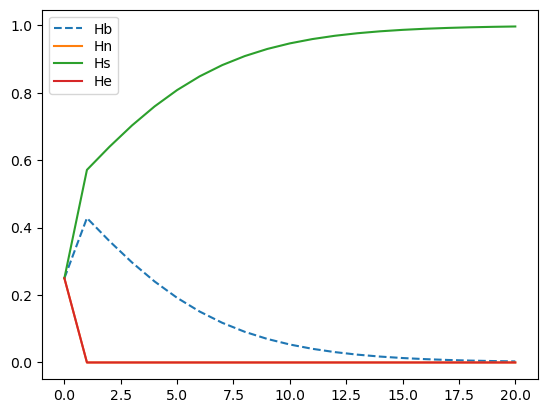

In [13]:
# run model on these data.  
# recursive bayesian updating: old posterior becomes new prior.
posts = {}  # posteriors, over time, per H
# initialize to list containing just the prior
for H in Hs:
    posts[H] = [prior[H]]
old_prior = prior
for elt in corpus:
    p = posterior(Hs, old_prior, lhood, elt)
    for H in Hs:
        posts[H].append(p[H])
    old_prior = p

Hb_post = posts['Hb'][:21]
Hn_post = posts['Hn'][:21]
Hs_post = posts['Hs'][:21]
He_post = posts['He'][:21]
plt.plot(Hb_post,'--',label='Hb')
plt.plot(Hn_post,label='Hn')
plt.plot(Hs_post,label='Hs')
plt.plot(He_post,label='He')
plt.legend(labelspacing=.25)
plt.show()

### Extensions (two are required!)

Please explore **at least two** extensions, **at least one of which** should be drawn from the following list.  The other extension may either be drawn from this list, or be of your own devising:
1. The base model assumes that the likelihood is given by a uniform distribution over possible data classes given a hypothesis - this assumption could be critiqued as simplistic in this context.  Explore other ways of modeling the production of linguistic data from a hypothesis.
2. The analyses below show degree of belief in hypotheses, as a function of number of exposures to relevant sorts of data - but this does not address how much **time** it takes for such data to appear, and therefore how long it would take a child to learn, given representative data.  Translate (approximately) the number of exposures into number of hours, by reference back to the data files (Suppes/\*.cha) - see how much actual time is needed for learning under various assumptions.

For each extension, include a brief writeup, in a markdown cell, of your observations, and separately, your conclusions.

---
**4 points for the following cell(s), on your first required extension.**

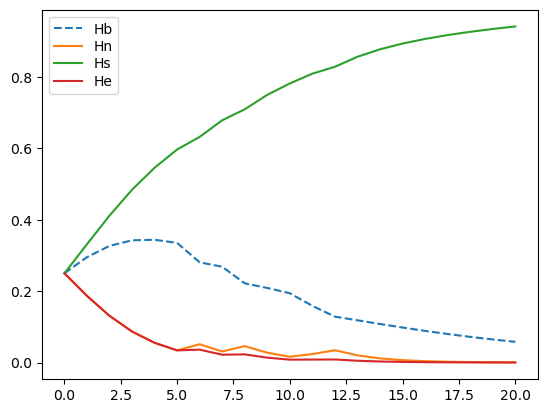

In [14]:
# Your first extension goes here.
# Question 1: It's clear that some utterances appear much more than others.
# What if children expected the more likely utterances, like it's at the start?

total = len(s_reduced) + len(s_full) + len(e_reduced) + len(e_full)

lhood={}
# likelihood for Hb : can reduce in both locations.
lhood[('sr','Hb')] = 1/4
lhood[('sf','Hb')] = 1/4
lhood[('er','Hb')] = 1/4
lhood[('ef','Hb')] = 1/4
# likelihood for Hn : can reduce in neither location.
lhood[('sr','Hn')] = 0.0 
lhood[('sf','Hn')] = 1/2
lhood[('er','Hn')] = 0.0
lhood[('ef','Hn')] = 1/2
# likelihood for Hs : can reduce at start but not at end.
lhood[('sr','Hs')] = 1/3
lhood[('sf','Hs')] = 1/3
lhood[('er','Hs')] = 0.0
lhood[('ef','Hs')] = 1/3
# likelihood for He : can reduce at end but not at start.
lhood[('sr','He')] = 0.0
lhood[('sf','He')] = 1/3
lhood[('er','He')] = 1/3
lhood[('ef','He')] = 1/3

# This determines how much seeing utterances impacts belief updating
bias = 0.5
# adding expectation
for key in lhood.keys():
    if key[0] == 'sr':
        lhood[key] = lhood[key] + len(s_reduced)/total * bias
    if key[0] == 'sf':
        lhood[key] = lhood[key] + len(s_full)/total * bias
    if key[0] == 'er':
        lhood[key] = lhood[key] + len(e_reduced)/total * bias
    if key[0] == 'ef':
        lhood[key] = lhood[key] + len(e_full)/total * bias
# renormalizing lhood
Hbtotal = 0
Hntotal = 0
Hstotal = 0
Hetotal = 0
for key in lhood.keys():
    if key[1] == 'Hb':
        Hbtotal += lhood[key]
    if key[1] == 'Hn':
        Hntotal += lhood[key]
    if key[1] == 'Hs':
        Hstotal += lhood[key]
    if key[1] == 'He':
        Hetotal += lhood[key]
for key in lhood.keys():
    if key[1] == 'Hb':
        lhood[key] = lhood[key] / Hbtotal
    if key[1] == 'Hn':
        lhood[key] = lhood[key] / Hntotal
    if key[1] == 'Hs':
        lhood[key] = lhood[key] / Hstotal
    if key[1] == 'He':
        lhood[key] = lhood[key] / Hetotal

# run model on these data.  
# recursive bayesian updating: old posterior becomes new prior.
posts = {}  # posteriors, over time, per H
# initialize to list containing just the prior
for H in Hs:
    posts[H] = [prior[H]]
old_prior = prior
for elt in corpus:
    p = posterior(Hs, old_prior, lhood, elt)
    for H in Hs:
        posts[H].append(p[H])
    old_prior = p

Hb_post = posts['Hb'][:21]
Hn_post = posts['Hn'][:21]
Hs_post = posts['Hs'][:21]
He_post = posts['He'][:21]
plt.plot(Hb_post,'--',label='Hb')
plt.plot(Hn_post,label='Hn')
plt.plot(Hs_post,label='Hs')
plt.plot(He_post,label='He')
plt.legend(labelspacing=.25)
plt.show()

### Observations

The general behavior looks really similar even after controlling for expecting more common utterances, which is really interesting. The learner seems to just take longer to come to the same conclusions. I suppose this makes sense, we basically just lowered the rate of updating, but not how the updating actually functions, so we should get the same eventual behavior. The big spike in Hb has been smoothed out significantly, which I also find interesting.

---
**4 points for the following cell(s), on your second required extension.**

### Extension 2

Some research has suggested that the complexity of a rule can impact its ability to be learned or represented in learners. 
Instead of giving each hypothesis the same prior, let's base the priors of the hypotheses on their complexity. We can estimate the Kolmogorov complexity of the rule, which is the length of the shortest algorithm that represents the rule. Here, we can represent each rule as a minimally complex python function...

Hb: def is_reduction_allowed(position): return true

Hn: def is_reduction_allowed(position): return false

Hs: def is_reduction_allowed(position): if position == front: return true else: return false

He: def is_reduction_allowed(position): if position == end: return true else: return false

...and we can see that Hs and He have longer and therefore more complex algorithms than Hb and Hn. If more complex rules are harder to represent or entertain, we can estimate that effect by lowering their priors in our model. 

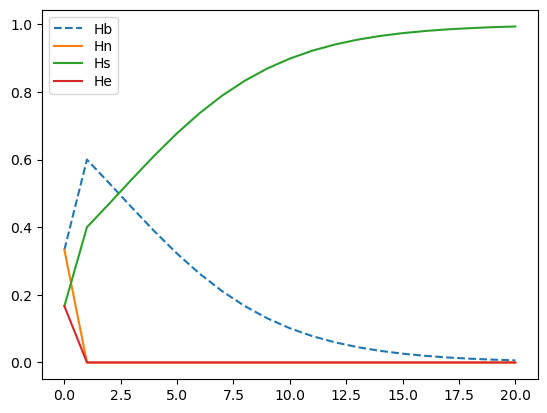

In [15]:
lhood={}
# likelihood for Hb : can reduce in both locations.
lhood[('sr','Hb')] = 1/4
lhood[('sf','Hb')] = 1/4
lhood[('er','Hb')] = 1/4
lhood[('ef','Hb')] = 1/4
# likelihood for Hn : can reduce in neither location.
lhood[('sr','Hn')] = 0.0 
lhood[('sf','Hn')] = 1/2
lhood[('er','Hn')] = 0.0
lhood[('ef','Hn')] = 1/2
# likelihood for Hs : can reduce at start but not at end.
lhood[('sr','Hs')] = 1/3
lhood[('sf','Hs')] = 1/3
lhood[('er','Hs')] = 0.0
lhood[('ef','Hs')] = 1/3
# likelihood for He : can reduce at end but not at start.
lhood[('sr','He')] = 0.0
lhood[('sf','He')] = 1/3
lhood[('er','He')] = 1/3
lhood[('ef','He')] = 1/3

# non-uniform prior
# Here, we estimate Hs and He to be twice as complex as Hb and Hn,
# and therefore to have half the prior weight as Hb and Hn.
prior = {}
prior['Hb'] = 1/3
prior['Hn'] = 1/3
prior['Hs'] = 1/6
prior['He'] = 1/6

# run model on these data.  
# recursive bayesian updating: old posterior becomes new prior.
posts = {}  # posteriors, over time, per H
# initialize to list containing just the prior
for H in Hs:
    posts[H] = [prior[H]]
old_prior = prior
for elt in corpus:
    p = posterior(Hs, old_prior, lhood, elt)
    for H in Hs:
        posts[H].append(p[H])
    old_prior = p

Hb_post = posts['Hb'][:21]
Hn_post = posts['Hn'][:21]
Hs_post = posts['Hs'][:21]
He_post = posts['He'][:21]
plt.plot(Hb_post,'--',label='Hb')
plt.plot(Hn_post,label='Hn')
plt.plot(Hs_post,label='Hs')
plt.plot(He_post,label='He')
plt.legend(labelspacing=.25)
plt.show()

### Comments

We can see at the left of the graph how the priors now start at different values. However the learning behavior hasn't changed. It takes the model longer to reach the same certainty that Hs is the right hypothesis, both because it starts at a lower probability and because the rate of change is lowered slightly, because the rate of learning is partially dependent on the prior. Eventually, though, the model reaches the same conclusion, and each hypothesis follows the same trend as in the original experiment

---
**4 points for the following cell, on optional extensions - but those points will be awarded only if you are not already at full credit.**

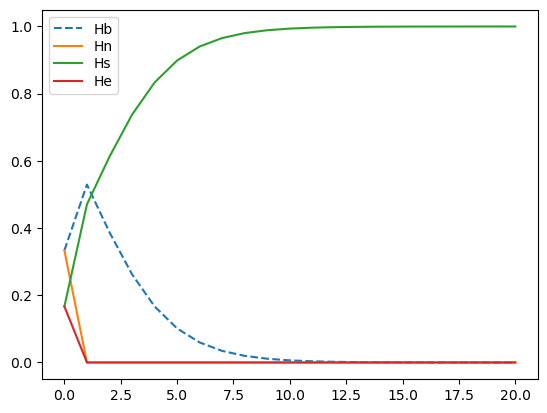

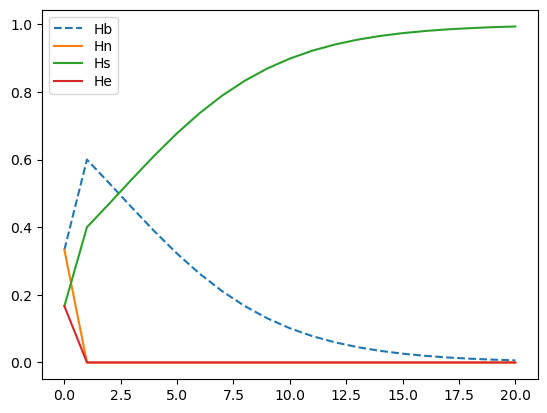

In [16]:
# Additional optional extensions may go here.

# Let's imagine a child that updates their beliefs based on new information twice as fast

def DougiePosterior(Hs, prior,lhood,d):
    # post IS A DICT: KEYS ARE HYPOTHESES AS SPECIFIED IN THE PASSED-IN
    # LIST Hs, AND CORRESPONDING VALUES ARE THE POSTERIOR PROBABILITY 
    # FOR THAT HYPOTHESIS, GIVEN THE DATAPOINT d PASSED IN, ASSUMING
    # PRIORS prior AND LIKELIHOODS lhood ALSO PASSED IN.
    post = {}
    # ** YOUR CODE GOES HERE.

    # Hs = ['Hb','Hn','Hs','He'], hypotheses
    # for H in Hs:
        # prior[H] = 1.0 / 4.0
    # lhood[(sr/sf/er/ef, Hb/Hb/Hs/He)] = probability of type given hypothesis
    #d = type

    #p(h|d) = p(d|h) * p(h)

    sum = 0
    for H in Hs:
        # we multiply the likelihood by 2, which makes induction happen faster
        post[H] = lhood[(d,H)] * prior[H] * lhood[(d,H)]
        sum += post[H]
    normalizing = 1/sum
    for H in Hs:
        post[H] = post[H] * normalizing
    return post


lhood={}
# likelihood for Hb : can reduce in both locations.
lhood[('sr','Hb')] = 1/4
lhood[('sf','Hb')] = 1/4
lhood[('er','Hb')] = 1/4
lhood[('ef','Hb')] = 1/4
# likelihood for Hn : can reduce in neither location.
lhood[('sr','Hn')] = 0.0 
lhood[('sf','Hn')] = 1/2
lhood[('er','Hn')] = 0.0
lhood[('ef','Hn')] = 1/2
# likelihood for Hs : can reduce at start but not at end.
lhood[('sr','Hs')] = 1/3
lhood[('sf','Hs')] = 1/3
lhood[('er','Hs')] = 0.0
lhood[('ef','Hs')] = 1/3
# likelihood for He : can reduce at end but not at start.
lhood[('sr','He')] = 0.0
lhood[('sf','He')] = 1/3
lhood[('er','He')] = 1/3
lhood[('ef','He')] = 1/3

# run model on these data.  
# recursive bayesian updating: old posterior becomes new prior.
posts = {}  # posteriors, over time, per H
# initialize to list containing just the prior
for H in Hs:
    posts[H] = [prior[H]]
old_prior = prior
for elt in corpus:
    p = DougiePosterior(Hs, old_prior, lhood, elt)
    for H in Hs:
        posts[H].append(p[H])
    old_prior = p

Hb_post = posts['Hb'][:21]
Hn_post = posts['Hn'][:21]
Hs_post = posts['Hs'][:21]
He_post = posts['He'][:21]
plt.plot(Hb_post,'--',label='Hb')
plt.plot(Hn_post,label='Hn')
plt.plot(Hs_post,label='Hs')
plt.plot(He_post,label='He')
plt.legend(labelspacing=.25)
plt.show()


# run model on these data.  
# recursive bayesian updating: old posterior becomes new prior.
posts = {}  # posteriors, over time, per H
# initialize to list containing just the prior
for H in Hs:
    posts[H] = [prior[H]]
old_prior = prior
for elt in corpus:
    p = posterior(Hs, old_prior, lhood, elt)
    for H in Hs:
        posts[H].append(p[H])
    old_prior = p

Hb_post = posts['Hb'][:21]
Hn_post = posts['Hn'][:21]
Hs_post = posts['Hs'][:21]
He_post = posts['He'][:21]
plt.plot(Hb_post,'--',label='Hb')
plt.plot(Hn_post,label='Hn')
plt.plot(Hs_post,label='Hs')
plt.plot(He_post,label='He')
plt.legend(labelspacing=.25)
plt.show()

### Comments

I was curious to see if this would cause any interesting behavior, but it seems to be pretty predictable — the model is just learned the same thing at a faster rate. If a learner were to remember what they had heard previously and revisit old utterances to re-update their beliefs, they could bootstrap their learning, similarly to how learning was bootstrapped in this model. Technically, the model to represent learning from recall would be more complex — there would be some random element of which utterances were remembered vs forgotten, and maybe some noise introduced in recalling previous utterances as well. If children do store and reuse previous utterances as they learn, it might help explain how they learn language so quickly. 